# <span style="color:rgb(213,80,0)">Run stand\-alone active material model with lithium plating</span>

In This example, we illustrate the implementation of Lithium plating.

The modeling equations are taken from

Hein, Danner and Latz "An Electrochemical Model of Lithium Plating and Stripping in Lithium Ion Batteries" In: ACS Applied Energy Materials (2022) [http://dx.doi.org/10.1021/acsaem.0c01155](http://dx.doi.org/10.1021/acsaem.0c01155)

## Parameter setup

We load a set of NMC\-graphite material parameters


In [1]:
filename = fullfile('ParameterData'        , ...
                    'BatteryCellParameters', ...
                    'LithiumIonBatteryCell', ...
                    'lithium_ion_battery_nmc_graphite.json');


jsonstruct = parseBattmoJson(filename);


We define some shortcuts


In [2]:
ne      = 'NegativeElectrode';
pe      = 'PositiveElectrode';
lp      = 'LithiumPlating';
co      = 'Coating';
am      = 'ActiveMaterial';
itf     = 'Interface';
sd      = 'SolidDiffusion';


We do not include the thermal effects


In [3]:
jsonstruct.use_thermal = false;


We include the lithium plating effect


In [4]:
jsonstruct.(ne).(co).(am).useLithiumPlating = true;


OCP is computed via a function described in the article (S\-5), which has been written as a matlab function `computeOCP_Graphite_Latz`. Let us plot this function



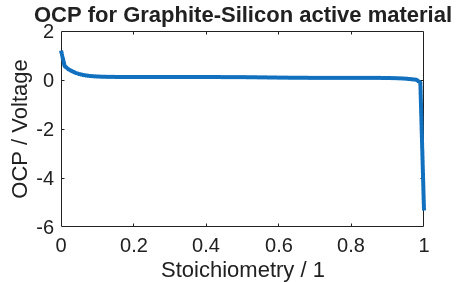

In [5]:
set(0, 'defaultlinelinewidth', 3);
set(0, 'defaultaxesfontsize', 15);


theta = linspace(0, 1, 100);
OCP = computeOCP_Graphite_Latz(theta);


plot(theta, OCP);
xlabel('Stoichiometry / 1')
ylabel('OCP / Voltage')
title('OCP for Graphite-Silicon active material')


We use this OCP function in our material. Note the use of the function interface. The function should be in the matlab path (this is the case here by installation default).


In [6]:
func.functionFormat = 'named function';
func.functionName   = 'computeOCP_Graphite_Latz';
func.argumentList   = {'stoichiometry'};


jsonstruct.(ne).(co).(am).(itf).openCircuitPotential = func;


We do not include the entropy change


In [7]:
jsonstruct.(ne).(co).(am).(itf).includeEntropyChange = false;


We load the lithium plating specific data


In [8]:
jsonstruct_lithium_plating = parseBattmoJson(fullfile('Examples', 'Advanced', 'Plating', 'lithium_plating.json'));
viewStruct(jsonstruct_lithium_plating);

{
  "LithiumPlating": {
    "symmetryFactorPlating": 0.3,
    "symmetryFactorStripping": 0.7,
    "symmetryFactorChemicalIntercalation": 0.5,
    "reactionRatePlating": 4.635E-6,
    "reactionRateChemicalIntercalation": 2.89E-9,
    "reactionRateDirectIntercalation": 6.656E-9,
    "thresholdParameter": 1.173E-23,
    "limitAmount": 1.173E-17,
    "platedLiMonolayerThickness": 2.78E-10
  }
}


We add this parameter set to our global parameter structure


In [9]:
jsonstruct.(ne).(co).(am).LithiumPlating = jsonstruct_lithium_plating.LithiumPlating;


We generate the `InputParams` structure. We do not have to do such step for a whole battery simulation. We do it know because we use a particle model and the interface for it is not yet as user friendly...


In [10]:
jsonstruct.(ne).(co).(am).isRootSimulationModel = true;
inputparams = BatteryInputParams(jsonstruct);
inputparams = inputparams.(ne).(co).(am);


We instantiate the active material model for the `inputparams` object


In [11]:
model = ActiveMaterial(inputparams);


We equip the model for simulation. Again, this step is done automatically for more main stream models.


In [12]:
model = model.setupForSimulation();


## Setup simulation schedule

We define the simulation schedule. Increasing Iref strengthens the effect.


In [13]:
Iref = 7e-13;
Imax = Iref;
total = 6e-3*hour*(Iref/Imax); % total time of the charge
n     = 400;
dt    = total/n;
step  = struct('val', dt*ones(n, 1), 'control', ones(n, 1));


tup = 1*second*(Iref/Imax);


srcfunc = @(time) rampupControl(time, tup, -Imax);


control.src = srcfunc;


schedule = struct('control', control, 'step', step);


## Setup initial state

In [14]:
sd  = 'SolidDiffusion';
itf = 'Interface';


cElectrolyte   = 5e-1*mol/litre;
phiElectrolyte = 0;
T              = 298;
cElectrodeInit = 30*mol/litre;


[model, initstate] = setupPlatingInitialState(model, T, cElectrolyte, phiElectrolyte, cElectrodeInit, Imax);


## Run first simulation, particle charge

In [15]:
inputSim = struct('model'    , model   , ...
                  'schedule' , schedule, ...
                  'initstate', initstate);
simsetup = SimulationSetup(inputSim);


states = simsetup.run();

In [16]:


chargeStates = states; % for later


## Setup discharge simulation

We use the last state of the previous simulation to initialise the new one


In [17]:
simsetup.initstate = states{end};


Setup schedule structure for discharge


In [18]:
cmin = (model.(itf).guestStoichiometry0)*(model.(itf).saturationConcentration);


control.stopFunction = @(model, state, state0_inner) (state.(sd).cSurface <= cmin);
control.src          = @(time) rampupControl(time, tup, Imax);


simsetup.schedule = struct('control', control, 'step', step);


## Run second simulation, particle discharge

In [19]:
states = simsetup.run();


We concatenate the two phases


In [20]:
dischargeStates = states;
states = vertcat(chargeStates, dischargeStates);


## Plotting


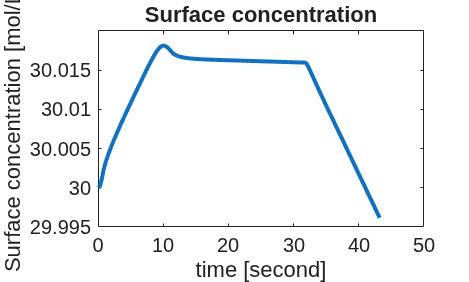

In [21]:
ind = cellfun(@(state) ~isempty(state), states);
states = states(ind);


time     = cellfun(@(state) state.time, states);
cSurface = cellfun(@(state) state.(sd).cSurface, states);
E        = cellfun(@(state) state.E, states);


figure
plot(time, cSurface/(1/litre));
xlabel('time [second]');
ylabel('Surface concentration [mol/L]');
title('Surface concentration');


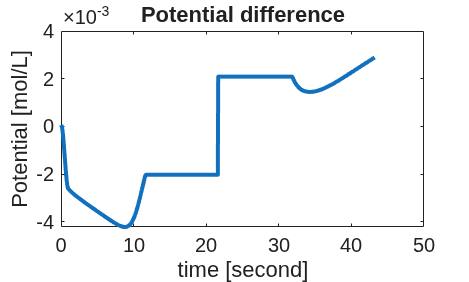

In [22]:


figure
plot(time, E);
xlabel('time [second]');
ylabel('Potential [mol/L]');
title('Potential difference');


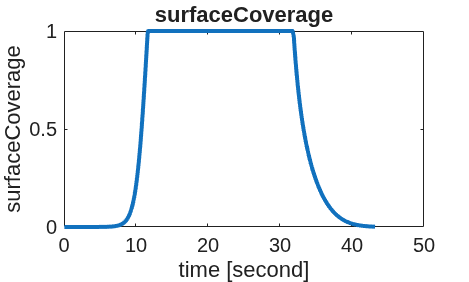

In [23]:


cmin = cellfun(@(state) min(state.(sd).c), states);
cmax = cellfun(@(state) max(state.(sd).c), states);


for istate = 1 : numel(states)
    states{istate} = model.evalVarName(states{istate}, {sd, 'cAverage'});
end


lp = 'LithiumPlating';


varsToEval = {{'Interface'     , 'eta'}         , ...
              {'LithiumPlating', 'etaPlating'}  , ...
              {'LithiumPlating', 'etaChemical'} , ...
              {'Interface'     , 'intercalationFlux'}           , ...
              {'LithiumPlating', 'platingFlux'} , ...
              {'LithiumPlating', 'chemicalFlux'}, ...
              {'LithiumPlating', 'surfaceCoverage'}, ...
              {'LithiumPlating', 'platedThickness'}};
for k = 1:numel(states)
    for var = 1:numel(varsToEval)
        states{k} = model.evalVarName(states{k}, varsToEval{var});
    end
end


varnames = {
            'platedConcentration', ...
            'eta', ...
            'etaPlating', ...
            'etaChemical', ...
            'platingFlux', ...
            'chemicalFlux', ...
            'intercalationFlux', ...
            'surfaceCoverage', ...
            'platedThickness'};


vars = {};


vsa = model.LithiumPlating.volumetricSurfaceArea;


vars{end + 1} = cellfun(@(s) s.(lp).platedConcentration, states);
vars{end + 1} = cellfun(@(s) s.(itf).eta, states);
vars{end + 1} = cellfun(@(s) s.(lp).etaPlating, states);
vars{end + 1} = cellfun(@(s) s.(lp).etaChemical, states);
vars{end + 1} = cellfun(@(s) s.(lp).platingFlux .* s.(lp).surfaceCoverage .* vsa, states);
vars{end + 1} = cellfun(@(s) s.(lp).chemicalFlux .* s.(lp).surfaceCoverage, states);
vars{end + 1} = cellfun(@(s) s.(itf).intercalationFlux .* (1 - s.(lp).surfaceCoverage), states);
vars{end + 1} = cellfun(@(s) s.(lp).surfaceCoverage, states);
vars{end + 1} = cellfun(@(s) s.(lp).platedThickness, states);


% Variable : surfaceCoverage
figure
plot(time, vars{8}, '-');
xlabel('time [second]');
ylabel(varnames{8});
title(varnames{8});


Area fraction that is plated. The more lithium is plated, the less it can pass from the electrolyte to intercalate into the electrode. Thus, if surfaceCoverage = 1, no more lithium can be intercalated from the solution. The electrode can still be filled with plated lithium through the chemical flux



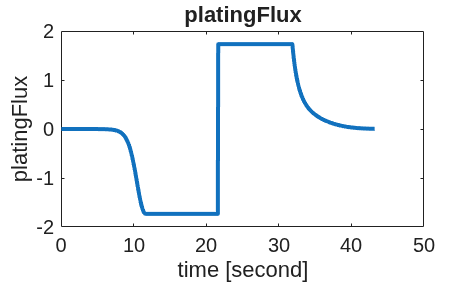

In [24]:
% Variable : platingFlux .* surfaceCoverage
%
figure
plot(time, vars{5}, '-');
xlabel('time [second]');
ylabel(varnames{5});
title(varnames{5});


We can see clearly here the 4 differents steps of the lithium plating phenomenon. First, at the end of the charge, the amount of lithium being plated grows faster and faster as the area where plating is possible increases.

Then, as the plated lithium covers the whole particle, the plating flux stabilises.

At the beginning of the discharge, the plated lithium begins to strip, as the plated layer is the only electron source available (the intercalated lithium has no contact with the electrolyte)



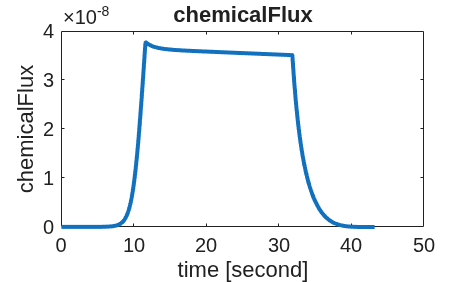

In [25]:
% Finally, the surfaceCoverage decreases, resulting in a slower stripping.


% Variable : chemicalFlux .* surfaceCoverage
figure
plot(time, vars{6}, '-');
xlabel('time [second]');
ylabel(varnames{6});
title(varnames{6});


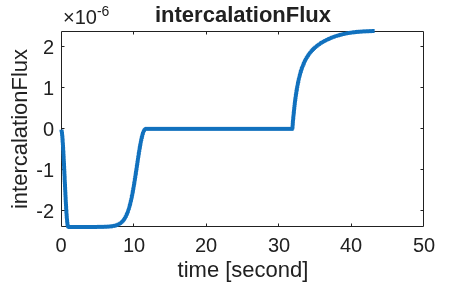

In [26]:


% Variable : intercalationFlux .* (1 - surfaceCoverage)
figure
plot(time, vars{7}, '-');
xlabel('time [second]');
ylabel(varnames{7});
title(varnames{7});


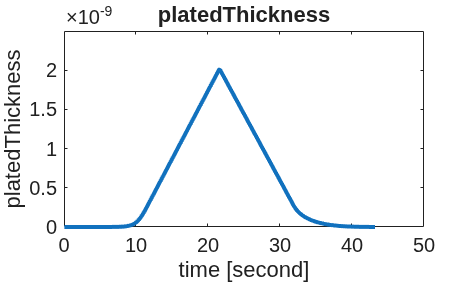

In [27]:
% No more lithium is intercalated during the time the whole surface is covered with plated lithium.


% Variable : platedThickness
figure
plot(time, vars{9}, '-');
xlabel('time [second]');
ylabel(varnames{9});
title(varnames{9});


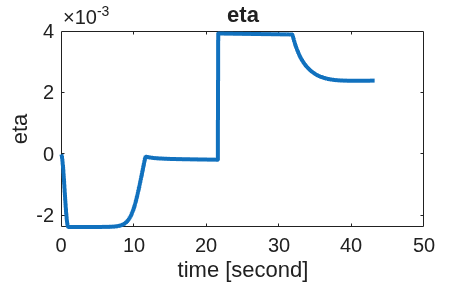

In [28]:


figure
plot(time, vars{2}, '-');
xlabel('time [second]');
ylabel(varnames{2});
title(varnames{2});


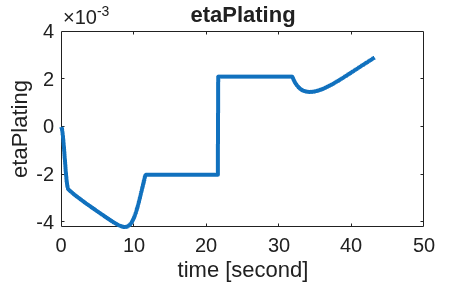

In [29]:


figure
plot(time, vars{3}, '-');
xlabel('time [second]');
ylabel(varnames{3});
title(varnames{3});


## Sum up


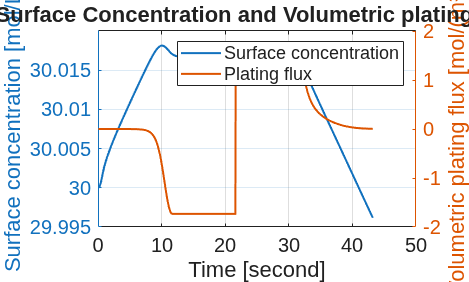

In [30]:
figure;


yyaxis left
plot(time, cSurface/(1/litre), '-', 'LineWidth', 1.5);
ylabel('Surface concentration [mol/L]');


yyaxis right
plot(time, vars{5}, '-', 'LineWidth', 1.5);
ylabel('Volumetric plating flux [mol/(m³·s)]');


xlabel('Time [second]');
title('Surface Concentration and Volumetric plating flux');
legend('Surface concentration', 'Plating flux');
grid on;